In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random

import numpy as np
from PIL import Image
import cv2
import albumentations as A
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [3]:
# def random_padding(img, **kwargs):
#     if img.dtype != np.uint8:
#         if img.max() <= 1.1:
#             img = (img * 255).astype(np.uint8)
#         else:
#             img = img.astype(np.uint8)

#     MAX_PADDING = 20
#     FILL = (255, 255, 255)

#     pl = np.random.randint(0, MAX_PADDING + 1)
#     pr = np.random.randint(0, MAX_PADDING + 1)
#     pt = np.random.randint(0, MAX_PADDING // 2 + 1)
#     pb = np.random.randint(0, MAX_PADDING // 2 + 1)

#     return cv2.copyMakeBorder(img, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=FILL)


# transform = A.Compose([
#     A.Lambda(image=random_padding, p=1.0),

#     A.ElasticTransform(
#         alpha=5,
#         sigma=20,
#         interpolation=cv2.INTER_LINEAR,
#         border_mode=cv2.BORDER_CONSTANT,
#         fill=(255, 255, 255),
#         p=0.7
#     ),

#     A.Affine(
#         scale={"x": (0.75, 1.25), "y": (0.75, 1.25)},
#         rotate=(-2, 2),
#         shear=(-3, 3),
#         fit_output=True,
#         border_mode=cv2.BORDER_CONSTANT,
#         fill=255,
#         fill_mask=255,
#         p=1.0
#     ),

#     A.Perspective(
#         scale=(0.02, 0.06),
#         keep_size=True,
#         fit_output=True,
#         border_mode=cv2.BORDER_CONSTANT,
#         fill=(255, 255, 255),
#         fill_mask=(255, 255, 255),
#         p=0.7
#     ),

#     A.GaussianBlur(
#         sigma_limit=(1.0, 3.0),
#         blur_limit=(3, 11),
#         p=1.0
#     ),

#     A.GaussNoise(
#         std_range=(0.1, 0.3), 
#         mean_range=(-0.3, 0.3),
#         p=1.0
#     ),

#     A.RandomBrightnessContrast(
#         brightness_limit=(-0.4, 0.4),
#         contrast_limit=(-0.4, 0.4),
#         ensure_safe_range=True,
#         p=1.0
#     ),
# ], seed=SEED)


In [4]:
def random_padding(img, **kwargs):
    if img.dtype != np.uint8:
        if img.max() <= 1.1:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

    MAX_PADDING = 20
    FILL = (255, 255, 255)

    pl = np.random.randint(0, MAX_PADDING + 1)
    pr = np.random.randint(0, MAX_PADDING + 1)
    pt = np.random.randint(0, MAX_PADDING // 2 + 1)
    pb = np.random.randint(0, MAX_PADDING // 2 + 1)

    return cv2.copyMakeBorder(img, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=FILL)


transform = A.Compose([
    A.Lambda(image=random_padding, p=1.0),

    A.OneOf([
        A.Morphological(
            scale=[3, 5],
            operation="dilation",
            p=1.0
        ),
        A.Morphological(
            scale=[3, 5],
            operation="erosion",
            p=1.0
        )
    ], p=0.8),

    A.OneOf([
        A.GridDistortion(
            num_steps=4,
            distort_limit=[-0.25, 0.25],
            normalized=True,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(255, 255, 255),
            p=1.0
        ),
        A.ElasticTransform(
            alpha=20,
            sigma=50,
            same_dxdy=False,
            noise_distribution="gaussian",
            border_mode=cv2.BORDER_CONSTANT,
            fill=(255, 255, 255),
            p=1.0
        ),
        A.ThinPlateSpline(
            scale_range=[0.02, 0.04],
            num_control_points=3,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(255, 255, 255),
            p=1.0
        ),
    ], p=0.8),

    A.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        rotate=(-2, 2),
        shear=(-3, 3),
        fit_output=True,
        border_mode=cv2.BORDER_CONSTANT,
        fill=(255, 255, 255),
        p=1.0
    ),

    A.GaussNoise(
        std_range=(0.1, 0.3),
        mean_range=(-0.3, 0.3),
        p=0.8
    ),

    A.OneOf([ 
        A.GaussianBlur(
            blur_limit=(3, 7),
            sigma_limit=(0.5, 2.5),
            p=1.0
        ),
        A.Downscale(
            scale_range=(0.75, 0.95),
            p=1.0
        ),
    ], p=1.0),

    A.RandomBrightnessContrast(
        brightness_limit=(-0.4, 0.4),
        contrast_limit=(-0.4, 0.4),
        ensure_safe_range=True,
        p=1.0
    ),

    A.Compose([
        A.PadIfNeeded(min_height=64, min_width=64, border_mode=cv2.BORDER_CONSTANT, fill=(255, 255, 255), p=1.0),
        A.LongestMaxSize(max_size_hw=(64, None), p=1.0),
    ], p=1.0),
], p=1.0, seed=SEED)


In [5]:
def augment_synthetic_dataset(
    csv_path: str,
    img_dir: str,
    save_img_dir: str,
    save_csv_path: str,
    transform,
    aug_per_image: int,
):
    os.makedirs(save_img_dir, exist_ok=True)
    if os.listdir(save_img_dir):
        raise RuntimeError(f"Directory {save_img_dir} is not empty")

    df = pd.read_csv(csv_path)
    augmented_rows = []

    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, row["image"])

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            continue
        image_np = np.array(image)

        for i in range(aug_per_image):
            aug = transform(image=image_np)
            aug_img_np = aug["image"]
            assert aug_img_np.ndim == 3 and aug_img_np.shape[2] == 3

            aug_img = Image.fromarray(aug_img_np)

            aug_name = f"{os.path.splitext(row['image'])[0]}_aug{i+1}.png"
            aug_img.save(os.path.join(save_img_dir, aug_name))

            aug_row = row.to_dict()
            aug_row["image"] = aug_name
            augmented_rows.append(aug_row)

    df_aug = pd.DataFrame(augmented_rows)
    df_aug.to_csv(save_csv_path, index=False)

    print(f"Augmented images saved to: {save_img_dir}")
    print(f"Augmented CSV saved to: {save_csv_path}")
    print(f"Total augmented images: {len(df_aug)}")



BASE_DATA_DIR = "data/word_nglegena_synthetic_20260124_160250"
AUG_PER_IMAGE = 3

augment_synthetic_dataset(
    csv_path=f"{BASE_DATA_DIR}/label_train.csv",
    img_dir=f"{BASE_DATA_DIR}/image_train",
    save_img_dir=f"{BASE_DATA_DIR}/image_train_aug",
    save_csv_path=f"{BASE_DATA_DIR}/label_train_aug.csv",
    transform=transform,
    aug_per_image=AUG_PER_IMAGE,
)


Augmented images saved to: data/word_nglegena_synthetic_20260124_160250/image_train_aug
Augmented CSV saved to: data/word_nglegena_synthetic_20260124_160250/label_train_aug.csv
Total augmented images: 3000


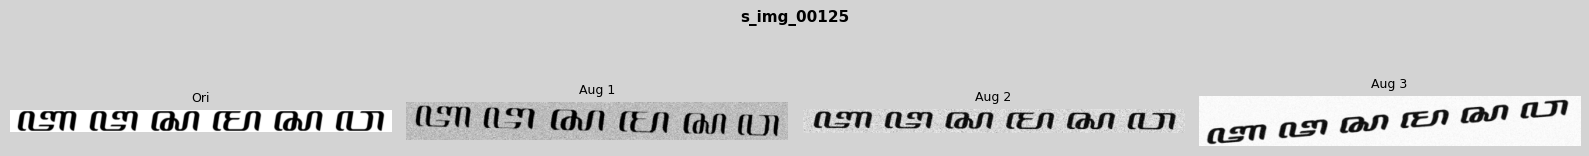

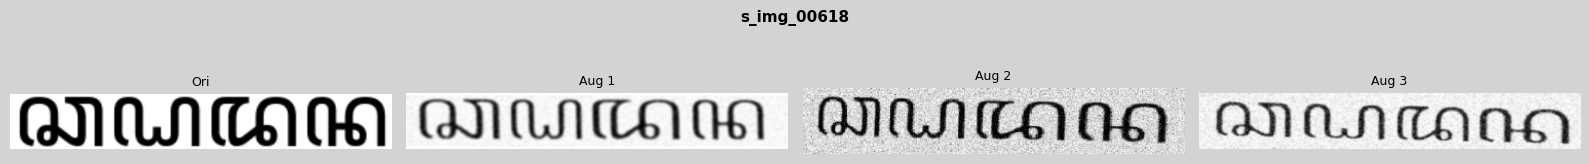

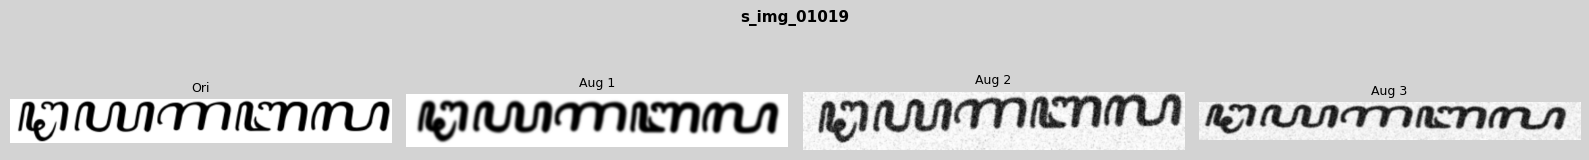

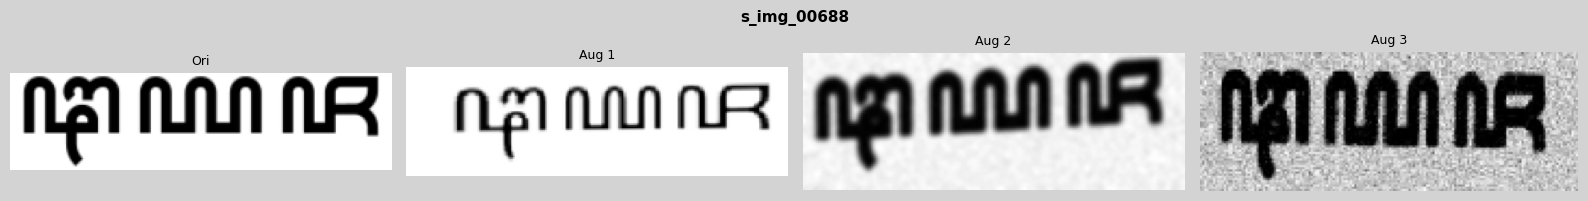

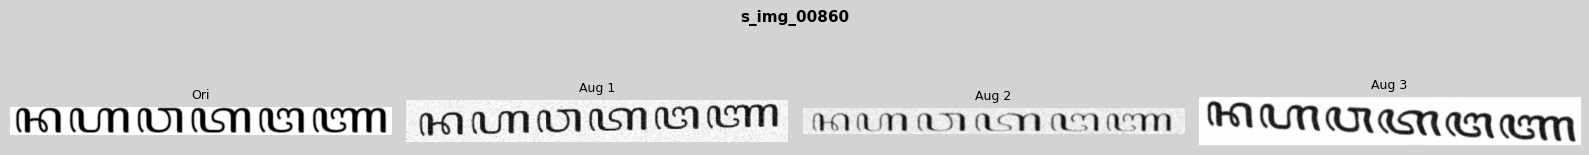

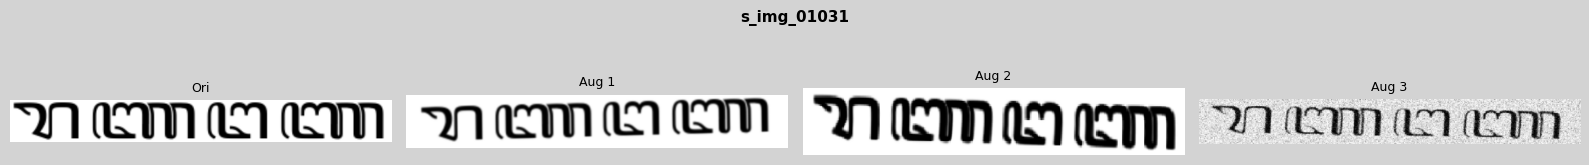

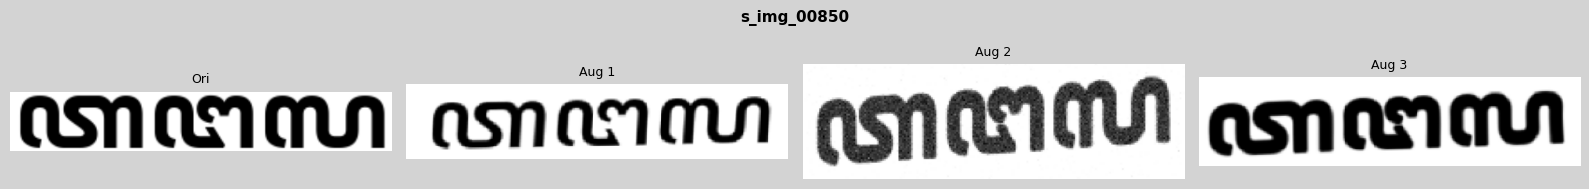

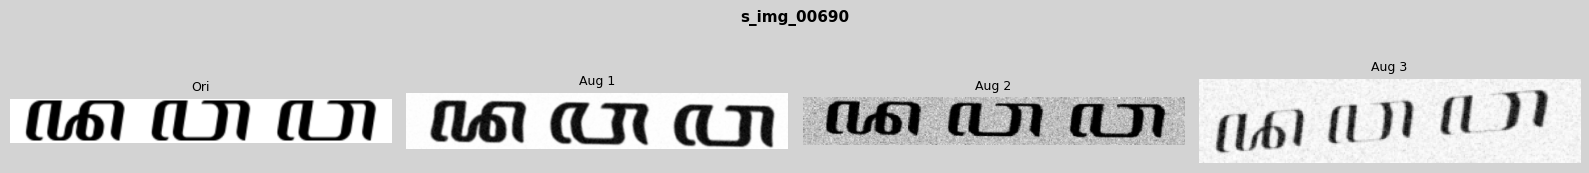

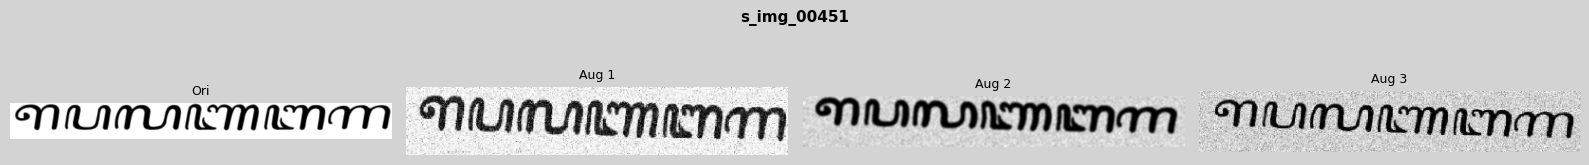

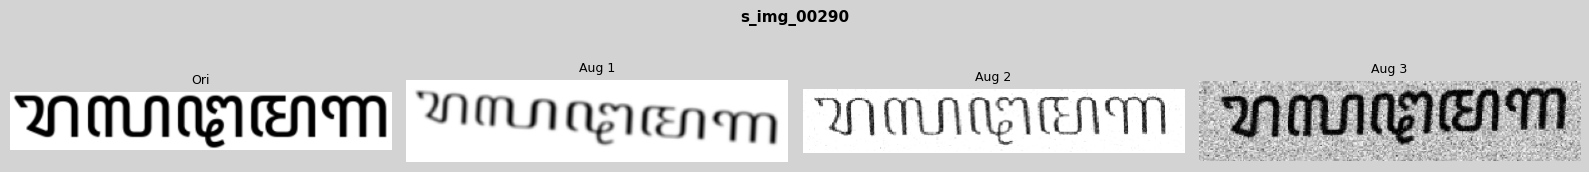

In [6]:
def visualize_augmentations(
    csv_ori,
    dir_ori,
    csv_aug,
    dir_aug,
    n_samples=5,
    max_aug=6,
):
    df_ori = pd.read_csv(csv_ori)
    df_aug = pd.read_csv(csv_aug)

    samples = df_ori.sample(n=min(n_samples, len(df_ori)), random_state=SEED)

    for _, row in samples.iterrows():
        base = row["image"].replace(".png", "")

        imgs = [Image.open(os.path.join(dir_ori, row["image"])).convert("L")]
        titles = ["Ori"]

        aug_rows = df_aug[df_aug["image"].str.startswith(base + "_aug")]
        for i, fname in enumerate(aug_rows["image"][:max_aug], 1):
            imgs.append(Image.open(os.path.join(dir_aug, fname)).convert("L"))
            titles.append(f"Aug {i}")

        fig, axes = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 2), facecolor="lightgray")
        if len(imgs) == 1:
            axes = [axes]

        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img, cmap="gray")
            ax.set_title(title, fontsize=9)
            ax.axis("off")

        plt.suptitle(base, fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()



BASE_DATA_DIR = "data/word_nglegena_synthetic_20260124_160250"
visualize_augmentations(
    csv_ori=f"{BASE_DATA_DIR}/label_train.csv",
    dir_ori=f"{BASE_DATA_DIR}/image_train",
    csv_aug=f"{BASE_DATA_DIR}/label_train_aug.csv",
    dir_aug=f"{BASE_DATA_DIR}/image_train_aug",
    n_samples=10,
    max_aug=4,
)
